In [6]:
import io
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# Municipal Securities Ownership by Sector
Source: Federal Reserve Z.1 Financial Accounts, Table L.212

In [ ]:
# ---------------------------------------------------------------------------
# Series definitions — asset/holder side of Z.1 Table L.212
# ---------------------------------------------------------------------------
SERIES = {
    "Households & Nonprofits":        "LM153062005",
    "Mutual Funds":                   "LM653062003",
    "ETFs":                           "LM563062003",
    "Money Market Funds":             "FL633062000",
    "Prop-Casualty Insurance":        "LM513062005",
    "Life Insurance":                 "LM543062005",
    "Depository Institutions":        "LM763062005",
    "State & Local Govts":            "LM213062003",
    "Retirement Funds (Fed)":         "LM343062033",
    "Retirement Funds (S&L)":         "LM223062043",
    "Foreign (Rest of World)":        "LM263062003",
    "Brokers & Dealers":              "LM663062005",
    "GSEs":                           "LM403062005",
    "Closed-End Funds":               "LM553062003",
    "Credit Unions":                  "LM473062005",
    "Other Financial":                "FL503062003",
    "Nonfin. Corporate":              "LM103062003",
    "Nonfin. Noncorporate":           "LM113062003",
    "Foreign Banks in US":            "LM753062003",
    "Banks in US-Affiliated Areas":   "LM743062003",
}

RAW_DIR = r"F:\Dropbox (Personal)\project\muni_bonds\data\raw\Fed"
os.makedirs(RAW_DIR, exist_ok=True)

FRED_CSV = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=BOGZ1{code}Q"

# ---------------------------------------------------------------------------
# Step 1: Download raw CSVs and save to disk
# ---------------------------------------------------------------------------
print("Downloading and saving raw Z.1 L.212 series from FRED...")
for label, code in SERIES.items():
    url = FRED_CSV.format(code=code)
    out_path = os.path.join(RAW_DIR, f"BOGZ1{code}Q.csv")
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        with open(out_path, "w") as f:
            f.write(resp.text)
        print(f"  saved  BOGZ1{code}Q.csv")
    except Exception as e:
        print(f"  FAILED {label} ({code}): {e}")

print(f"\nRaw files saved to: {RAW_DIR}")

  saved  BOGZ1LM153062005Q.csv
  saved  BOGZ1LM653062003Q.csv
  saved  BOGZ1LM563062003Q.csv
  saved  BOGZ1FL633062000Q.csv
  saved  BOGZ1LM513062005Q.csv
  saved  BOGZ1LM543062005Q.csv
  saved  BOGZ1LM763062005Q.csv
  saved  BOGZ1LM213062003Q.csv
  saved  BOGZ1LM343062033Q.csv
  saved  BOGZ1LM223062043Q.csv
  saved  BOGZ1LM263062003Q.csv
  saved  BOGZ1LM663062005Q.csv
  saved  BOGZ1LM403062005Q.csv
  saved  BOGZ1LM553062003Q.csv
  saved  BOGZ1LM473062005Q.csv
  saved  BOGZ1FL503062003Q.csv
  saved  BOGZ1LM103062003Q.csv
  saved  BOGZ1LM113062003Q.csv
  saved  BOGZ1LM753062003Q.csv
  saved  BOGZ1LM743062003Q.csv

Raw files saved to: F:\Dropbox (Personal)\project\muni_bonds\data\raw\Fed
Data spans 1945–2025  (302 quarters)


In [11]:
# ---------------------------------------------------------------------------
# Step 2: Load saved CSVs and merge into one DataFrame
# ---------------------------------------------------------------------------
frames = {}
for label, code in SERIES.items():
    path = os.path.join(RAW_DIR, f"BOGZ1{code}Q.csv")
    if not os.path.exists(path):
        print(f"  MISSING {label}")
        continue
    df = pd.read_csv(path, parse_dates=["observation_date"])
    df = df.rename(columns={"observation_date": "date"})
    df = df.set_index("date")
    df.columns = [label]
    df[label] = pd.to_numeric(df[label], errors="coerce")
    frames[label] = df[label]

raw_df = pd.DataFrame(frames)
df_tr = (raw_df / 1_000).dropna(how="all")   # billions → trillions
print(f"Data spans {df_tr.index.min().year}–{df_tr.index.max().year}  ({len(df_tr)} quarters)")

Data spans 1945–2025  (302 quarters)


In [16]:
# ---------------------------------------------------------------------------
# Categorize ownership
# ---------------------------------------------------------------------------
df_plot = df_tr.copy()

# Insurance = P&C + Life combined
df_plot["Insurance"] = (
    df_plot.pop("Prop-Casualty Insurance").fillna(0)
    + df_plot.pop("Life Insurance").fillna(0)
)

# Mutual Funds = open-end + ETFs
df_plot["Mutual Funds (Open-End & ETF)"] = (
    df_plot.pop("Mutual Funds").fillna(0)
    + df_plot.pop("ETFs").fillna(0)
)

# Retirement Funds = federal + state & local employee pension funds
df_plot["Retirement Funds"] = (
    df_plot.pop("Retirement Funds (Fed)").fillna(0)
    + df_plot.pop("Retirement Funds (S&L)").fillna(0)
)

# Other Funds = closed-end funds + other financial business (hedge funds etc.)
df_plot["Other Funds"] = (
    df_plot.pop("Closed-End Funds").fillna(0)
    + df_plot.pop("Other Financial").fillna(0)
)

# Rename
df_plot = df_plot.rename(columns={
    "Households & Nonprofits": "Households",
    "Foreign (Rest of World)": "Rest of World",
})

# Remaining small holders → Other
other_cols = [
    "Depository Institutions", "State & Local Govts",
    "Brokers & Dealers", "GSEs", "Credit Unions",
    "Nonfin. Corporate", "Nonfin. Noncorporate",
    "Foreign Banks in US", "Banks in US-Affiliated Areas",
]
other_cols = [c for c in other_cols if c in df_plot.columns]
df_plot["Other"] = df_plot[other_cols].fillna(0).sum(axis=1)
df_plot = df_plot.drop(columns=other_cols)

# Display order
ORDER = [
    "Households",
    "Insurance",
    "Mutual Funds (Open-End & ETF)",
    "Money Market Funds",
    "Closed-End Funds" if "Closed-End Funds" in df_plot.columns else None,
    "Retirement Funds",
    "Other Funds",
    "Rest of World",
    "Other",
]
ORDER = [c for c in ORDER if c and c in df_plot.columns]
df_plot = df_plot[ORDER]
df_plot = df_plot[df_plot.sum(axis=1) > 0]

print("Latest quarter holdings:")
for col in df_plot.columns:
    print(f"  {col:35s}  ${df_plot[col].iloc[-1]:.2f}T")

Latest quarter holdings:
  Households                           $2038.29T
  Insurance                            $379.00T
  Mutual Funds (Open-End & ETF)        $990.74T
  Money Market Funds                   $139.70T
  Retirement Funds                     $0.03T
  Other Funds                          $70.10T
  Rest of World                        $125.75T
  Other                                $477.54T


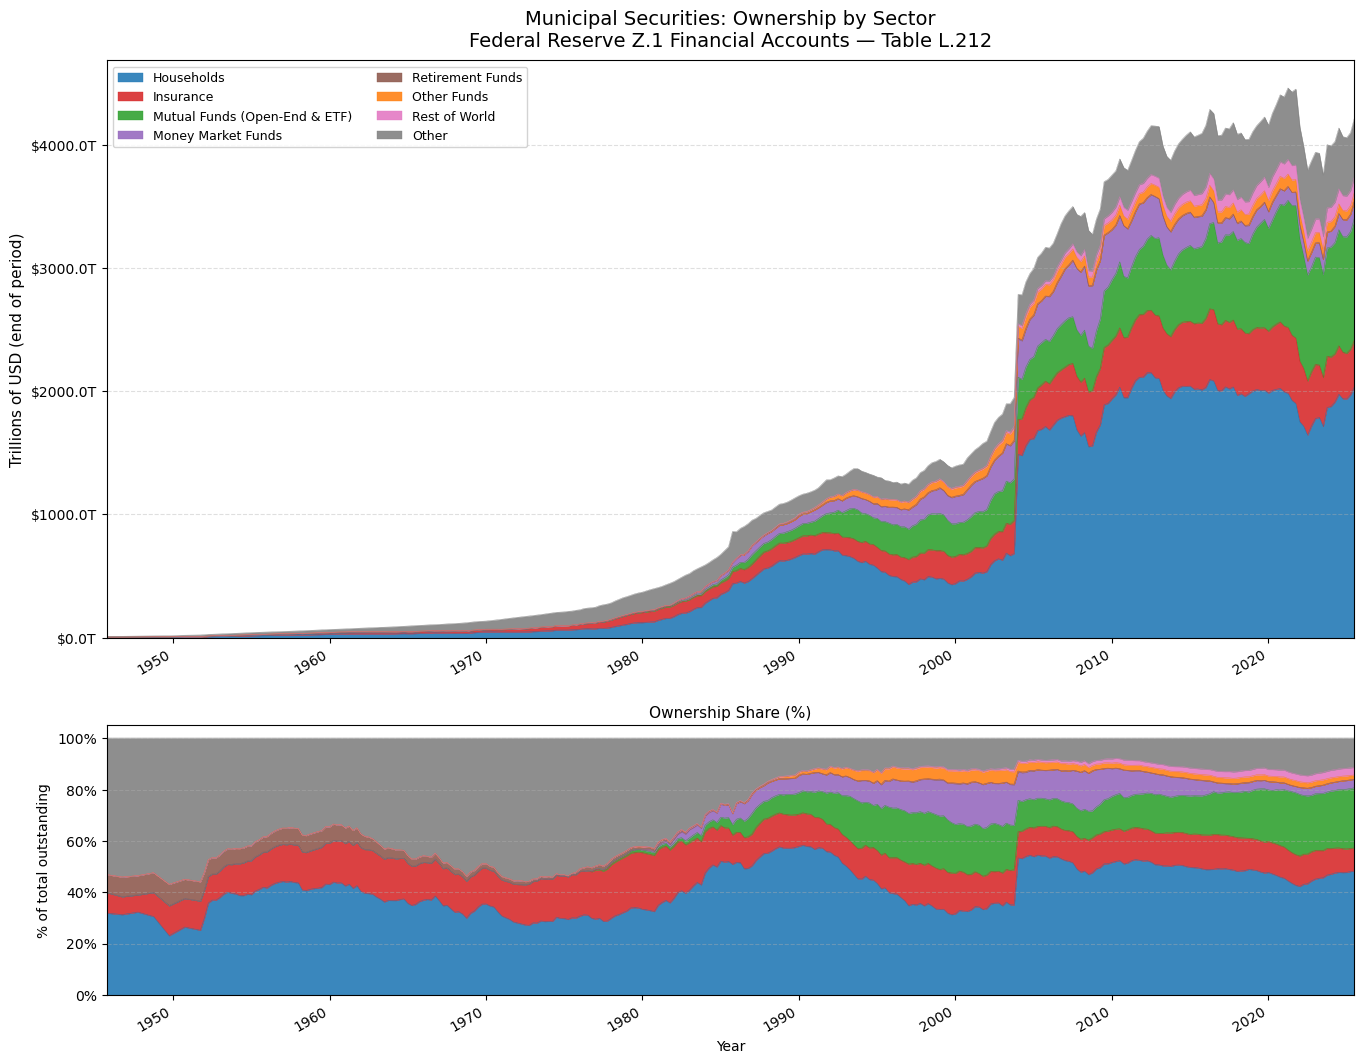

In [17]:
# ---------------------------------------------------------------------------
# Plot: stacked area (levels) + share (%)
# ---------------------------------------------------------------------------
COLORS = [
    "#1f77b4",  # Households
    "#d62728",  # Insurance
    "#2ca02c",  # Mutual Funds (Open-End & ETF)
    "#9467bd",  # Money Market Funds
    "#8c564b",  # Retirement Funds
    "#ff7f0e",  # Other Funds
    "#e377c2",  # Rest of World
    "#7f7f7f",  # Other
    "#17becf",  # extra
]
colors = COLORS[:len(df_plot.columns)]

fig, axes = plt.subplots(2, 1, figsize=(14, 11),
                         gridspec_kw={"height_ratios": [3, 1.4]})

ax = axes[0]
df_plot.plot.area(ax=ax, color=colors, linewidth=0.3, alpha=0.88)
ax.set_title(
    "Municipal Securities: Ownership by Sector\n"
    "Federal Reserve Z.1 Financial Accounts — Table L.212",
    fontsize=14, pad=10,
)
ax.set_ylabel("Trillions of USD (end of period)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}T"))
ax.legend(loc="upper left", fontsize=9, framealpha=0.85, ncol=2)
ax.set_xlim(df_plot.index.min(), df_plot.index.max())
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_xlabel("")

ax2 = axes[1]
df_share = df_plot.div(df_plot.sum(axis=1), axis=0).mul(100)
df_share.plot.area(ax=ax2, color=colors, linewidth=0.3, alpha=0.88, legend=False)
ax2.set_title("Ownership Share (%)", fontsize=11)
ax2.set_ylabel("% of total outstanding", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.set_xlim(df_plot.index.min(), df_plot.index.max())
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.set_xlabel("Year")

fig.tight_layout(pad=2)
plt.savefig("muni_ownership.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# ---------------------------------------------------------------------------
# Categorize ownership — US holders only
# ---------------------------------------------------------------------------
df_plot = df_tr.copy()

# Drop foreign holders (focus on US)
df_plot = df_plot.drop(columns=["Foreign (Rest of World)", "Foreign Banks in US",
                                 "Banks in US-Affiliated Areas"], errors="ignore")

# Insurance = P&C + Life combined
df_plot["Insurance"] = (
    df_plot.pop("Prop-Casualty Insurance").fillna(0)
    + df_plot.pop("Life Insurance").fillna(0)
)

# Mutual Funds = open-end + ETFs
df_plot["Mutual Funds (Open-End & ETF)"] = (
    df_plot.pop("Mutual Funds").fillna(0)
    + df_plot.pop("ETFs").fillna(0)
)

# Retirement Funds = federal + state & local employee pension funds
df_plot["Retirement Funds"] = (
    df_plot.pop("Retirement Funds (Fed)").fillna(0)
    + df_plot.pop("Retirement Funds (S&L)").fillna(0)
)

# Other Funds = closed-end funds + other financial business
df_plot["Other Funds"] = (
    df_plot.pop("Closed-End Funds").fillna(0)
    + df_plot.pop("Other Financial").fillna(0)
)

# Rename
df_plot = df_plot.rename(columns={"Households & Nonprofits": "Households"})

# Remaining holders → Other
other_cols = ["Depository Institutions", "State & Local Govts", "Brokers & Dealers",
              "GSEs", "Credit Unions", "Nonfin. Corporate", "Nonfin. Noncorporate"]
other_cols = [c for c in other_cols if c in df_plot.columns]
df_plot["Other"] = df_plot[other_cols].fillna(0).sum(axis=1)
df_plot = df_plot.drop(columns=other_cols)

# Institutional = everything except Households
INSTITUTIONAL = ["Insurance", "Mutual Funds (Open-End & ETF)", "Money Market Funds",
                  "Retirement Funds", "Other Funds", "Other"]

ORDER = ["Households"] + INSTITUTIONAL
df_plot = df_plot[[c for c in ORDER if c in df_plot.columns]]
df_plot = df_plot[df_plot.sum(axis=1) > 0]

# Summary series
total_us    = df_plot.sum(axis=1)
inst_share  = df_plot[INSTITUTIONAL].sum(axis=1) / total_us * 100
hh_share    = df_plot["Households"] / total_us * 100

print("Latest quarter (US only):")
for col in df_plot.columns:
    pct = df_plot[col].iloc[-1] / total_us.iloc[-1] * 100
    print(f"  {col:35s}  ${df_plot[col].iloc[-1]:.2f}T  ({pct:.1f}%)")
print(f"\n  {'Institutional total':35s}  {inst_share.iloc[-1]:.1f}%")
print(f"  {'Households':35s}  {hh_share.iloc[-1]:.1f}%")

Latest quarter (US only):
  Households                           $2038.29T  (49.8%)
  Insurance                            $379.00T  (9.3%)
  Mutual Funds (Open-End & ETF)        $990.74T  (24.2%)
  Money Market Funds                   $139.70T  (3.4%)
  Retirement Funds                     $0.03T  (0.0%)
  Other Funds                          $70.10T  (1.7%)
  Other                                $477.29T  (11.7%)

  Institutional total                  50.2%
  Households                           49.8%


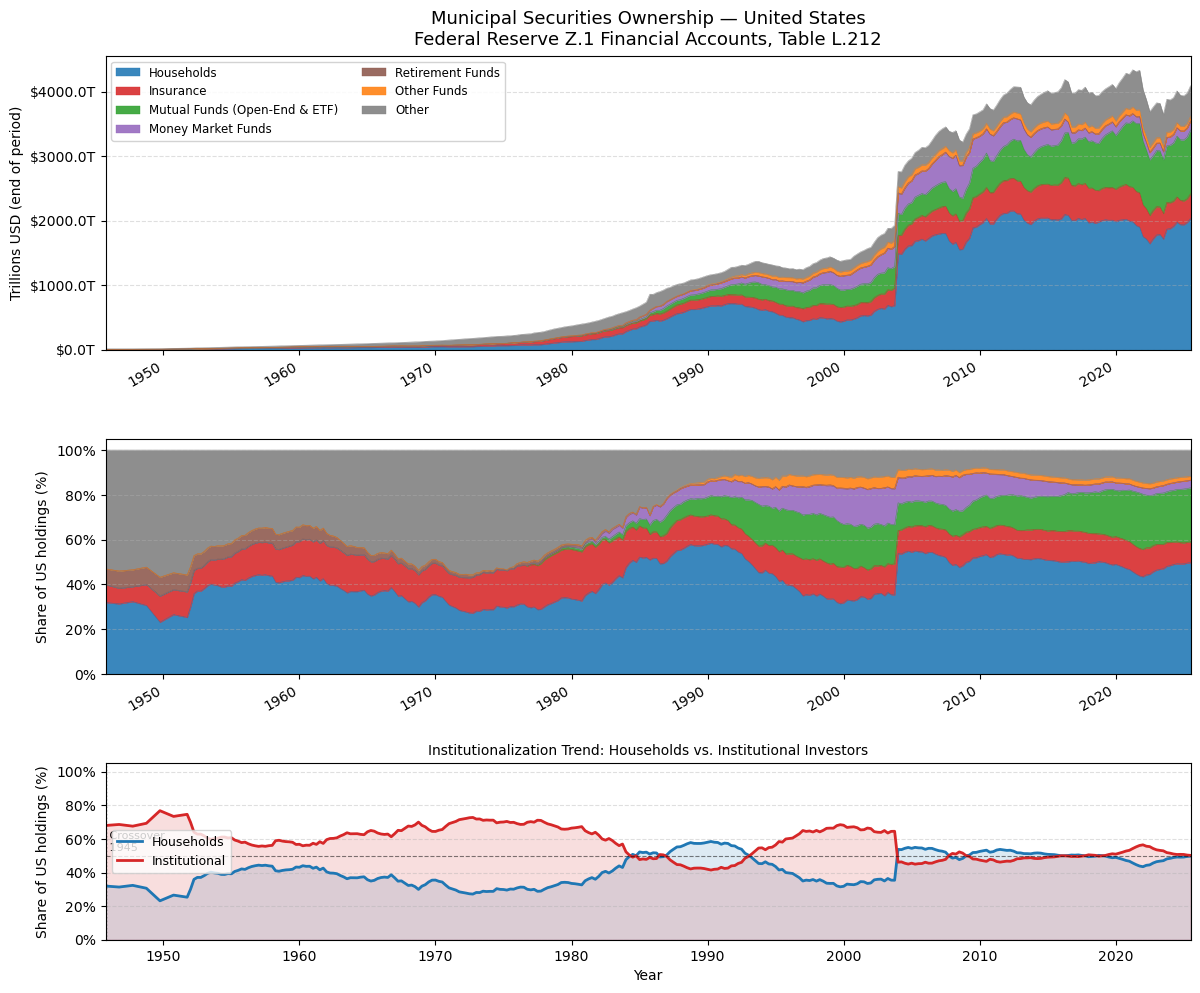

In [19]:
# ---------------------------------------------------------------------------
# Plot: institutionalization trend
# ---------------------------------------------------------------------------
COLORS = {
    "Households":                  "#1f77b4",
    "Insurance":                   "#d62728",
    "Mutual Funds (Open-End & ETF)":"#2ca02c",
    "Money Market Funds":          "#9467bd",
    "Retirement Funds":            "#8c564b",
    "Other Funds":                 "#ff7f0e",
    "Other":                       "#7f7f7f",
}
colors = [COLORS[c] for c in df_plot.columns]

inst_cols = [c for c in df_plot.columns if c != "Households"]
df_share  = df_plot.div(total_us, axis=0).mul(100)

fig = plt.figure(figsize=(14, 13))
gs  = fig.add_gridspec(3, 1, height_ratios=[2, 1.6, 1.2], hspace=0.38)

# ── Panel 1: stacked area — absolute levels ──────────────────────────────
ax1 = fig.add_subplot(gs[0])
df_plot.plot.area(ax=ax1, color=colors, linewidth=0.3, alpha=0.88)
ax1.set_title(
    "Municipal Securities Ownership — United States\n"
    "Federal Reserve Z.1 Financial Accounts, Table L.212",
    fontsize=13, pad=8,
)
ax1.set_ylabel("Trillions USD (end of period)", fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}T"))
ax1.legend(loc="upper left", fontsize=8.5, framealpha=0.85, ncol=2)
ax1.set_xlim(df_plot.index.min(), df_plot.index.max())
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.set_xlabel("")

# ── Panel 2: stacked area — ownership share (%) ──────────────────────────
ax2 = fig.add_subplot(gs[1])
df_share.plot.area(ax=ax2, color=colors, linewidth=0.3, alpha=0.88, legend=False)
ax2.set_ylabel("Share of US holdings (%)", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.set_xlim(df_plot.index.min(), df_plot.index.max())
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.set_xlabel("")

# ── Panel 3: institutionalization line — Household vs Institutional ───────
ax3 = fig.add_subplot(gs[2])
ax3.plot(hh_share.index,   hh_share.values,   color="#1f77b4", lw=2,   label="Households")
ax3.fill_between(hh_share.index, hh_share.values, alpha=0.15, color="#1f77b4")
ax3.plot(inst_share.index, inst_share.values, color="#d62728", lw=2,   label="Institutional")
ax3.fill_between(inst_share.index, inst_share.values, alpha=0.15, color="#d62728")
ax3.axhline(50, color="black", lw=0.8, linestyle="--", alpha=0.5)

# Mark crossover
cross_idx = (inst_share >= hh_share).idxmax()
if pd.notna(cross_idx):
    ax3.axvline(cross_idx, color="black", lw=1, linestyle=":", alpha=0.7)
    ax3.text(cross_idx, 52, f" Crossover\n {cross_idx.year}",
             fontsize=8, va="bottom", color="black")

ax3.set_ylabel("Share of US holdings (%)", fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax3.set_xlim(df_plot.index.min(), df_plot.index.max())
ax3.set_ylim(0, 105)
ax3.legend(fontsize=9, loc="center left")
ax3.set_title("Institutionalization Trend: Households vs. Institutional Investors", fontsize=10)
ax3.grid(axis="y", linestyle="--", alpha=0.4)
ax3.set_xlabel("Year")

plt.savefig("muni_ownership.png", dpi=150, bbox_inches="tight")
plt.show()